# Step 1b (Quarantine) — Do the OTHER survey items track the sentiment trajectory?

**Two questions**
- **1b.3** For each sentiment model, how strongly does its group-level valence correlate with *each*
  of the 16 behavioral items? (What do the models actually track — just emotion, or a broad
  "good-person" halo?)
- **1b.4** Which behavioral items co-move with the `positive emotion` item itself? (Is our sentiment
  ground truth an isolated construct, or one face of a bundle?)





## 1b.1 · Rebuild the group-level behavioral trajectories (all 16 items)

Same loader logic as Step 1.1 (auto-locate `data/charsurvey/`, NaN-safe, run = block), but here we
**keep all 16 items** instead of collapsing to one target. Output `gt_all`: one row per
`(group, Character, Run)` with 16 item columns, averaged across the ~12-14 participants per group.

In [6]:
import pandas as pd, numpy as np, scipy.io as sio
from pathlib import Path
from scipy.stats import spearmanr

CHARACTERS  = ["jack", "kate", "kevin", "randall"]
CHAR_COLS   = ["jack", "kate", "randall", "kevin"]   # block column order (instruction.pdf p.6)
_CANDIDATES = [Path("data/charsurvey"), Path("charsurvey"),
               Path("socialaha-beh/charsurvey"), Path("data/socialaha-beh/charsurvey")]
BEH_DIR     = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
ITEM_LABELS = [str(x[0]) for x in sio.loadmat(BEH_DIR / "labels.mat")["labels"].ravel()]

def group_from_id(pid):
    d = [c for c in str(pid) if c.isdigit()]
    return int(d[0]) if d else np.nan

def load_participant(path):
    pid = Path(path).stem
    m = sio.loadmat(path)
    rows = []
    for b in range(1, 11):                          # block{1..10} == Run 1..10
        blk = m[f"block{b}"].astype(float)          # float keeps NaN (skipped ratings)
        for ci, ch in enumerate(CHAR_COLS):
            rec = {"Participant": pid, "group": group_from_id(pid), "Character": ch, "Run": b}
            for ri, lab in enumerate(ITEM_LABELS):
                rec[lab] = float(blk[ri, ci])       # never impute; means below skip NaN
            rows.append(rec)
    return pd.DataFrame(rows)

mat_files = sorted(p for p in BEH_DIR.glob("s*.mat") if p.name != "labels.mat")
assert mat_files, f"No s*.mat in {BEH_DIR.resolve()}"
beh = pd.concat([load_participant(p) for p in mat_files], ignore_index=True)
beh["Character"] = beh["Character"].str.lower().str.strip()
beh = beh[beh["Character"].isin(CHARACTERS)]

# group-level trajectories, ALL 16 items (skipna=True averaging)
gt_all = beh.groupby(["group", "Character", "Run"])[ITEM_LABELS].mean().reset_index()
print("gt_all shape:", gt_all.shape, "| expect 120 x (3 keys + 16 items)")
gt_all.head()

gt_all shape: (120, 19) | expect 120 x (3 keys + 16 items)


,group,Character,Run,warm and kind,intelligent,agreeable,extraverted,impulsive,emotionally stable,open-minded,trustworthy,competent,rational behavior,positive emotion,good relationship,empathize,understand,like,similar
0,1,jack,1,5.666667,4.500000,5.333333,5.166667,3.916667,5.083333,4.833333,5.250000,5.416667,5.500000,6.500000,6.166667,4.250000,3.250000,4.833333,3.166667
1,1,jack,2,6.153846,4.923077,5.461538,5.230769,4.153846,5.846154,5.153846,5.769231,5.461538,5.923077,5.230769,6.307692,5.000000,4.923077,5.615385,2.846154
2,1,jack,3,6.000000,4.923077,5.000000,5.461538,4.846154,3.846154,4.230769,5.692308,5.538462,4.307692,4.384615,6.230769,5.307692,5.461538,5.461538,2.923077
3,1,jack,4,6.076923,5.307692,5.615385,5.076923,3.846154,3.692308,4.923077,5.538462,5.769231,5.692308,2.307692,5.615385,6.153846,5.769231,5.615385,3.307692
4,1,jack,5,6.461538,5.153846,5.461538,5.307692,4.230769,4.461538,4.615385,5.846154,5.615385,5.461538,4.076923,6.230769,5.384615,5.615385,5.615385,3.230769


i wonder if doing this against dialogue from each chracter at each run would work

## 1b.2 · Group-level sentiment valence per model

Reuse  Step-0 baselines. 
Valence = `positive - negative` for the four classifiers,

I THINK THIS IS NOT AS UPDATED AS IT COULD BE
`WINNER` = the Step-1 contest winner, used as the reference sentiment
trajectory for sorting.

In [7]:
MODEL_FILES = {
    "Twitter_RoB": "results/baselines/00__character_vectors_simple_Twitter_RoB.csv",
    "RoBERTa_ZS":  "results/baselines/00__character_vectors_simple_RoBERTa_ZS.csv",
    "VADER":       "results/baselines/00__character_vectors_simple_VADER.csv",
    "Flair":       "results/baselines/00__character_vectors_simple_Flair.csv",
    "SiEBERT":     "results/baselines/00__character_vectors_simple_SiEBERT.csv",
    "BERTweet":    "results/baselines/00__character_vectors_simple_BERTweet.csv",
    "Warriner":    "results/baselines/00b__character_vectors_simple_Warriner_val.csv",
    "NRC_VAD":     "results/baselines/00b__character_vectors_simple_NRC_VAD_val.csv",
}
WINNER = "Twitter_RoB"   # from Step 1 step1_model_ranking.csv

model_wide = None
model_names = []
for name, path in MODEL_FILES.items():
    try:
        d = pd.read_csv(path)
    except FileNotFoundError:
        print(f"[skip {name}: {path} not found]"); continue
    d["Character"] = d["Character"].str.lower().str.strip()
    if {"positive", "negative"}.issubset(d.columns):
        d["valence"] = d["positive"] - d["negative"]
    elif "valence" not in d.columns:
        print(f"[skip {name}: no valence]"); continue
    d["group"] = d["Participant"].map(group_from_id)
    d = d[d["Run"].between(1, 10)]                   # drop Step-0 Run==-1 sentinel
    g = (d.groupby(["group", "Character", "Run"])["valence"].mean()
           .reset_index().rename(columns={"valence": f"val_{name}"}))
    model_wide = g if model_wide is None else model_wide.merge(g, on=["group","Character","Run"])
    model_names.append(name)

print("models:", model_names, "| winner:", WINNER)
print("model_wide shape:", model_wide.shape)
model_wide.head()

models: ['Twitter_RoB', 'RoBERTa_ZS', 'VADER', 'Flair', 'SiEBERT', 'BERTweet', 'Warriner', 'NRC_VAD'] | winner: Twitter_RoB
model_wide shape: (120, 11)


,group,Character,Run,val_Twitter_RoB,val_RoBERTa_ZS,val_VADER,val_Flair,val_SiEBERT,val_BERTweet,val_Warriner,val_NRC_VAD
0,1,jack,1,0.581772,0.523932,0.250700,0.240496,0.595928,0.715146,6.752304,0.237147
1,1,jack,2,0.225646,0.359850,0.218800,-0.107349,0.793089,0.372690,6.439768,0.250213
2,1,jack,3,0.311435,0.287277,0.154222,0.313648,0.773358,0.535940,6.486589,0.250931
3,1,jack,4,-0.275483,-0.514790,0.019300,-0.135989,-0.000018,-0.352026,6.076541,0.166815
4,1,jack,5,0.222133,0.069263,0.143500,-0.180384,0.012778,0.401915,6.529373,0.225643


## 1b.3 · Does each survey item track model sentiment?

In [8]:
merged = gt_all.merge(model_wide, on=["group", "Character", "Run"], how="inner")

rows = []
for item in ITEM_LABELS:
    row = {"survey_item": item}
    for name in model_names:
        rho, p = spearmanr(merged[item], merged[f"val_{name}"], nan_policy="omit")
        row[name] = round(rho, 3)
    rows.append(row)

item_vs_model = (pd.DataFrame(rows)
                   .sort_values(WINNER, ascending=False)
                   .reset_index(drop=True))
Path("results/step1b").mkdir(parents=True, exist_ok=True)
item_vs_model.to_csv("results/step1b/01b__step1b_item_vs_model_spearman.csv", index=False)
print(f"Spearman(item trajectory, model valence)  -- sorted by {WINNER}:")
print(item_vs_model.to_string(index=False))

Spearman(item trajectory, model valence)  -- sorted by Twitter_RoB:
       survey_item  Twitter_RoB  RoBERTa_ZS  VADER  Flair  SiEBERT  BERTweet  Warriner  NRC_VAD
  positive emotion        0.588       0.534  0.451  0.388    0.289     0.506     0.449    0.145
emotionally stable        0.569       0.511  0.425  0.470    0.305     0.506     0.460    0.226
       open-minded        0.526       0.441  0.352  0.522    0.367     0.460     0.377    0.234
 good relationship        0.508       0.471  0.367  0.443    0.354     0.457     0.354    0.096
         competent        0.487       0.388  0.278  0.559    0.399     0.430     0.444    0.354
       trustworthy        0.476       0.393  0.320  0.523    0.359     0.435     0.375    0.220
     warm and kind        0.474       0.435  0.360  0.482    0.351     0.427     0.317    0.125
         agreeable        0.467       0.387  0.320  0.492    0.311     0.388     0.329    0.164
 rational behavior        0.431       0.380  0.291  0.377    0.210  

should make a visualization of the above table

## 1b.4 · Which behavioral items co-move with the sentiment item?

A Spearman correlation matrix among the 16 survey items plus the winning model's valence, over the
120 group-level rows. The column for `positive emotion` (and for `val_<WINNER>`) tells you which
constructs bundle with sentiment. A heatmap makes the clusters visible.

WHY DO WE DO THIS WITH POSITIVE EMOTOIN RATHER THAN LIKE

Spearman with 'positive emotion' (survey), ranked:
emotionally stable    0.886
good relationship     0.711
rational behavior     0.701
warm and kind         0.628
open-minded           0.624
agreeable             0.613
val_Twitter_RoB       0.588
trustworthy           0.539
like                  0.514
competent             0.470
understand            0.374
intelligent           0.365
similar               0.337
empathize             0.250
extraverted          -0.080
impulsive            -0.380

Spearman with model sentiment val_Twitter_RoB, ranked:
positive emotion      0.588
emotionally stable    0.569
open-minded           0.526
good relationship     0.508
competent             0.487
trustworthy           0.476
warm and kind         0.474
agreeable             0.467
rational behavior     0.431
like                  0.388
intelligent           0.384
understand            0.314
similar               0.227
empathize             0.212
extraverted          -0.106
impulsive            -0.2

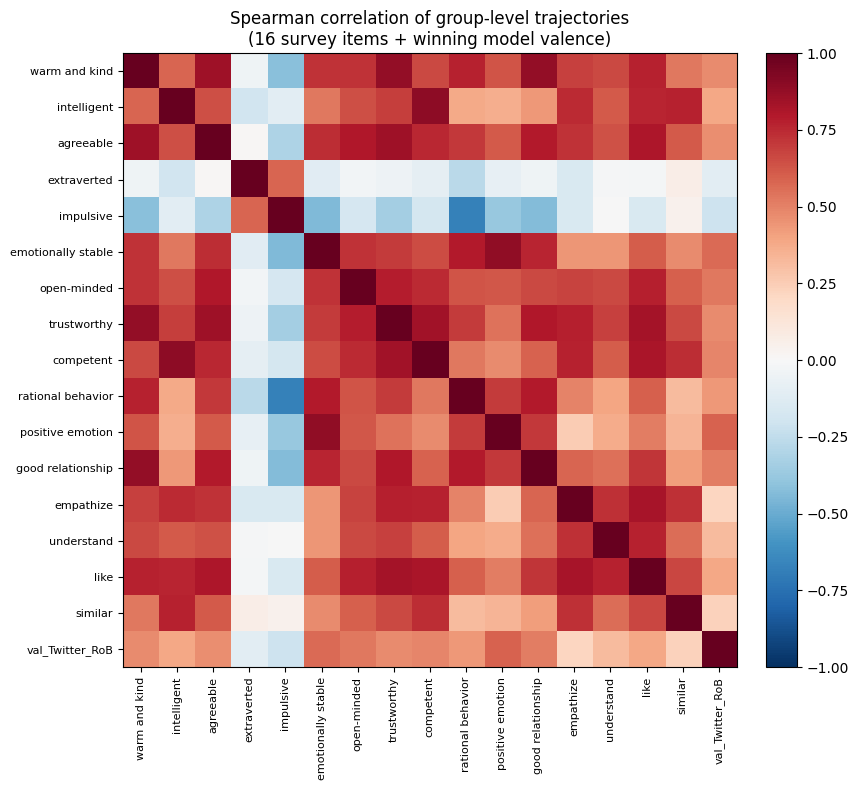

saved step1b_correlation_heatmap.png


In [9]:
cols = ITEM_LABELS + [f"val_{WINNER}"]
corr = merged[cols].corr(method="spearman")

# what co-moves with the sentiment item, ranked
print("Spearman with 'positive emotion' (survey), ranked:")
print(corr["positive emotion"].drop("positive emotion").sort_values(ascending=False).round(3).to_string())
print()
print(f"Spearman with model sentiment val_{WINNER}, ranked:")
print(corr[f"val_{WINNER}"].drop(f"val_{WINNER}").sort_values(ascending=False).round(3).to_string())
corr.to_csv("results/step1b/01b__step1b_item_correlation_matrix.csv")

# heatmap (optional viz)
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=8)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
    ax.set_title("Spearman correlation of group-level trajectories\n(16 survey items + winning model valence)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.savefig("results/step1b/01b__step1b_correlation_heatmap.png", dpi=140); plt.show()
    print("saved step1b_correlation_heatmap.png")
except Exception as e:
    print("heatmap skipped:", e)

## Findings — what the sentiment signal actually tracks (output above)
the model's
"sentiment" is really a broad **evaluative "good-person" halo**, not emotion

also survey shows the same bundling internally: `positive emotion` correlates 0.89 with `emotionally
stable`, 0.71 with `good relationship`, 0.70 with `rational behavior`, and 0.63 with `warm and kind`.
So the ground-truth target is itself one face of a general **positivity dimension** — the valence axis
that social-cognitive neuroscience (Tamir et al. 2016) says organizes person representation in the brain.

**Boundary of the representation.** Items that *don't* move with valence — `intelligent`, `extraverted`,
`impulsive` — mark what a valence-only sentiment vector cannot capture, motivating richer non-valence
features (impressions / USE, per the parent paper) at the brain step.

**Note (curiosity):** `Flair` and `Warriner` correlate more with trait/competence items (e.g. Flair
with `competent` 0.534, `intelligent` 0.509) than with `positive emotion`. a hint they track a
slightly different, more "trait-like" signal than the transformers' cleaner valence.

**Still exploratory / descriptive** — 16×6 correlations at the group level; see the caveats cell below.

## 1b.5 · Follow-ups from my notes

Addresses: "make a visualization of the table", "why positive emotion rather than like?", "we should try
[BH-FDR]", and refreshing 1b.2. Additive — notes above unchanged.

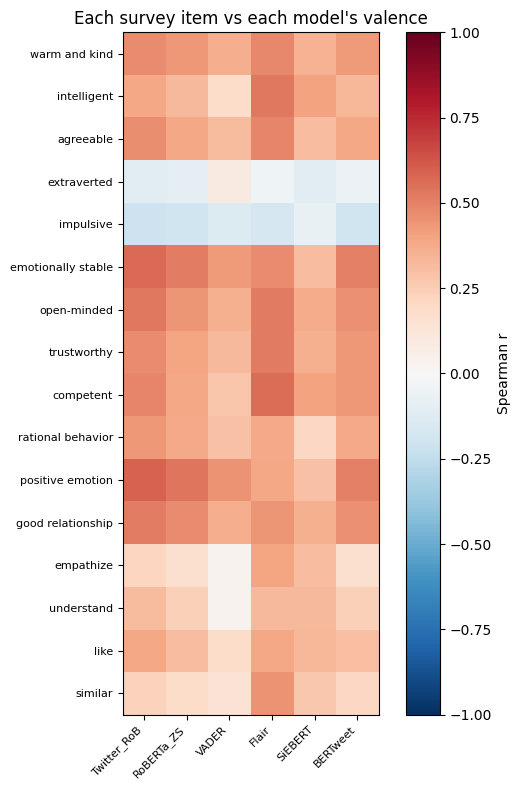

BH-FDR: 80 of 96 item×model correlations survive q<.05
              item       model     r   p  q_BH  survives_q<.05
  positive emotion Twitter_RoB 0.588 0.0   0.0            True
emotionally stable Twitter_RoB 0.569 0.0   0.0            True
         competent       Flair 0.559 0.0   0.0            True
  positive emotion  RoBERTa_ZS 0.534 0.0   0.0            True
       open-minded Twitter_RoB 0.526 0.0   0.0            True
       intelligent       Flair 0.526 0.0   0.0            True
       trustworthy       Flair 0.523 0.0   0.0            True
       open-minded       Flair 0.522 0.0   0.0            True
emotionally stable  RoBERTa_ZS 0.511 0.0   0.0            True
emotionally stable    BERTweet 0.506 0.0   0.0            True
  positive emotion    BERTweet 0.506 0.0   0.0            True
 good relationship Twitter_RoB 0.508 0.0   0.0            True

Which items co-move with `like` vs with `positive emotion` (group level, Pearson):
                    vs_positive_emotion  v

In [10]:
# 1b.5  Heatmap of item x model agreement + the `like` version + BH-FDR survivors.
import pandas as pd, numpy as np, scipy.io as sio, matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
gt = pd.read_csv("results/step1/01__ground_truth_group_level.csv"); gt["Character"] = gt["Character"].str.lower().str.strip()
ITEMS = [str(x[0]) for x in sio.loadmat(Path("data/charsurvey")/"labels.mat")["labels"].ravel()]
MODELS = ["Twitter_RoB","RoBERTa_ZS","VADER","Flair","SiEBERT","BERTweet"]
g = ["group","Character","Run"]
def mval(name):
    d = pd.read_csv(f"results/baselines/00__character_vectors_simple_{name}.csv")
    d["Character"] = d["Character"].str.lower().str.strip(); d["v"] = d["positive"] - d["negative"]
    d["group"] = d["Participant"].astype(str).str.extract(r"(\d)").astype(int); d = d[d["Run"].between(1,10)]
    return d.groupby(g)["v"].mean().rename(name)
M = pd.concat([mval(m) for m in MODELS], axis=1).reset_index()
J = gt[g+ITEMS].merge(M, on=g)

# (a) item x model Spearman heatmap  [addresses "make a visualization"]
R = np.array([[spearmanr(J[it], J[mm])[0] for mm in MODELS] for it in ITEMS])
fig, ax = plt.subplots(figsize=(6, 8)); im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ITEMS))); ax.set_yticklabels(ITEMS, fontsize=8)
fig.colorbar(im, label="Spearman r"); ax.set_title("Each survey item vs each model's valence")
fig.tight_layout(); fig.savefig("results/step1b/01b__item_vs_model_heatmap.png", dpi=140, bbox_inches="tight"); plt.show()

# (b) BH-FDR survivors on all 16 items x 6 models  [addresses "we should try [FDR]"]
rows = [(it, mm, *spearmanr(J[it], J[mm])) for it in ITEMS for mm in MODELS]
fdr = pd.DataFrame(rows, columns=["item","model","r","p"])
fdr["q_BH"] = multipletests(fdr["p"], method="fdr_bh")[1]
fdr["survives_q<.05"] = fdr["q_BH"] < 0.05
print(f"BH-FDR: {int(fdr['survives_q<.05'].sum())} of {len(fdr)} item×model correlations survive q<.05")
print(fdr[fdr["survives_q<.05"]].sort_values("q_BH").head(12).round(3).to_string(index=False))

# (c) `like` version  [addresses "WHY positive emotion rather than like?"]
print("\nWhich items co-move with `like` vs with `positive emotion` (group level, Pearson):")
cmp = pd.DataFrame({"vs_positive_emotion": gt[ITEMS].corrwith(gt["positive emotion"]),
                    "vs_like":             gt[ITEMS].corrwith(gt["like"])}).round(2).sort_values("vs_positive_emotion", ascending=False)
print(cmp.to_string())

**Why `positive emotion`, not `like`, is the primary reference (answering my note).** `positive emotion`
is the item the *models actually track* (Step 1: cv-R² 0.34 vs ~0 for `like`), so it's the meaningful
"anchor" to ask what else co-moves with. `like` is the participant's own attitude, which the sentiment
signal doesn't capture — so a `like`-anchored halo would mostly reflect the survey's internal structure,
not the model. Both columns are shown above so the contrast is explicit. **1b.2 refresh:** the group-level
valence here is rebuilt from all six current Step-0 baselines (not a stale subset).

*Flagged for Hayoung* (from my caveat note): are any halo items (`trustworthy`, `empathize`) worth
promoting to a secondary validation target, or kept purely as descriptive context? — added to the meeting
brief's open decisions.

## ASK HAYOUNG!!
- **ASK HAYOUNG!!** Promote a halo item (`trustworthy` / `empathize`) to a secondary validation target, or keep purely descriptive? *(lean: descriptive)*

## Interpretation & caveats

**How to read it.**
- If non-valence trait items (`trustworthy`, `warm and kind`, `agreeable`, `competent`) correlate with
  model valence *almost as strongly* as `positive emotion` does, the sentiment models are picking up a
  broad **evaluative / "good person" halo**, not emotion 
- If viewer-stance items (`empathize`, `understand`, `like`, `similar`) track valence, that speaks to
  how felt positivity relates to engagement with a character.
- Items that *don't* move with valence (e.g. `intelligent`, `rational behavior`, `impulsive`) mark the
  boundary of what a valence-only sentiment representation can capture — motivating richer, non-valence
  features later (impressions / USE, per the parent paper).

**Caveats.**
1. **Exploratory, not confirmatory.** 16 items x 6 models = 96 correlations; treat as descriptive.
   Apply Benjamini-Hochberg FDR if you want to flag "survivors":
   `from statsmodels.stats.multitest import multipletests`.
   WE SHOULD TRY THIS
2. **Group-level.** Same ecological-fallacy / inflated-effect-size caveats as Step 1 — conclusions are
   about group trajectories, not individuals.
3. **This does not change model selection.** The primary contest still uses `positive emotion`; this
   notebook only characterizes *what else* the sentiment signal happens to align with.

** question for Hayoung:** are any of these items (e.g. `trustworthy`, `empathize`) worth promoting
to a secondary validation target, or kept purely as this descriptive context?